In [5]:
import datetime
import os
import ee
import geemap
import matplotlib.pyplot as plt

from identify_locations import identify_forests, identify_route_buffer
from read_and_process_hls import compute_hls_indices
from fit_greendown_curves import compute_transition_dates, compute_average_transition_dates
from filter_ci_widths import count_narrow_ci_pixel_years
from build_data_table import build_feature_table
from edit_data_table import edit_feature_table
from plot_feature_distributions import plot_feature_distributions
from decision_trees import split_data, fit_tree
from sklearn.metrics import accuracy_score, classification_report, mean_absolute_error
from sklearn import tree

ee.Initialize(project='turnkey-lacing-391919')

OUTPUT_DIR = './greendown_outputs'
os.makedirs(OUTPUT_DIR, exist_ok=True)

ma_forest    = identify_forests()
route_buffer = identify_route_buffer()

start_year    = 2013 #First HLS year
previous_year = 2025

# ----------------------------
# Fit logistic curves for each year
# ----------------------------
all_year_paths = []
for y in range(start_year, previous_year + 1):
    print(f'Processing {y}...')
    hls   = compute_hls_indices(route_buffer, ma_forest, y)
    paths = compute_transition_dates(hls, route_buffer, ma_forest, y, output_dir=OUTPUT_DIR)
    all_year_paths.append(paths)

prev_year_paths = all_year_paths[-1]   # most recent year

# ----------------------------
# Average transition dates across all years
# ----------------------------
print('Computing averages...')
avg_paths = compute_average_transition_dates(all_year_paths, output_dir=OUTPUT_DIR)

# ----------------------------
# Filter: pixels with CI width < 15 days for all transitions
# ----------------------------
print('\nFiltering pixel-years by CI width...')
years = list(range(start_year, previous_year + 1))
count_narrow_ci_pixel_years(OUTPUT_DIR, years)

# ----------------------------
# Build labeled EVI/NDVI feature table and plot distributions
# ----------------------------
print('\nBuilding labeled feature table...')
feature_df = build_feature_table(OUTPUT_DIR, years)
#plot_feature_distributions(feature_df)
feature_df_edited = edit_feature_table(feature_df, OUTPUT_DIR)
print(feature_df_edited.head())
print('\nNaN counts per column:')
print(feature_df_edited.isna().sum())
#plot_feature_distributions(feature_df_edited)


Processing 2013...
  Using cached results for 2013
Processing 2014...
  Using cached results for 2014
Processing 2015...
  Using cached results for 2015
Processing 2016...
  Using cached results for 2016
Processing 2017...
  Using cached results for 2017
Processing 2018...
  Using cached results for 2018
Processing 2019...
  Using cached results for 2019
Processing 2020...
  Using cached results for 2020
Processing 2021...
  Using cached results for 2021
Processing 2022...
  Using cached results for 2022
Processing 2023...
  Using cached results for 2023
Processing 2024...
  Using cached results for 2024
Processing 2025...
  Using cached results for 2025
Computing averages...


/Users/Kathryn/Documents/Professional Development/Google Earth Engine/AppTrail_Phenology/fit_greendown_curves.py:337: RuntimeWarning: Mean of empty slice
  mean = np.nanmean(np.stack(arrays, axis=0), axis=0).astype(np.float32)



Filtering pixel-years by CI width...
  2013: 600 pixels (all phases)  |  start: 610  middle: 859  end: 606
  2014: 229 pixels (all phases)  |  start: 268  middle: 913  end: 244
  2015: 403 pixels (all phases)  |  start: 496  middle: 2290  end: 473
  2016: 282 pixels (all phases)  |  start: 288  middle: 435  end: 286
  2017: 186 pixels (all phases)  |  start: 197  middle: 621  end: 204
  2018: 920 pixels (all phases)  |  start: 932  middle: 1240  end: 925
  2019: 157 pixels (all phases)  |  start: 172  middle: 606  end: 180
  2020: 155 pixels (all phases)  |  start: 164  middle: 299  end: 164
  2021: 440 pixels (all phases)  |  start: 454  middle: 797  end: 462
  2022: 409 pixels (all phases)  |  start: 526  middle: 1420  end: 534
  2023: 500 pixels (all phases)  |  start: 697  middle: 2193  end: 833
  2024: 423 pixels (all phases)  |  start: 780  middle: 1162  end: 562
  2025: 323 pixels (all phases)  |  start: 429  middle: 941  end: 474

Total pixel-years with all CI widths < 15 days

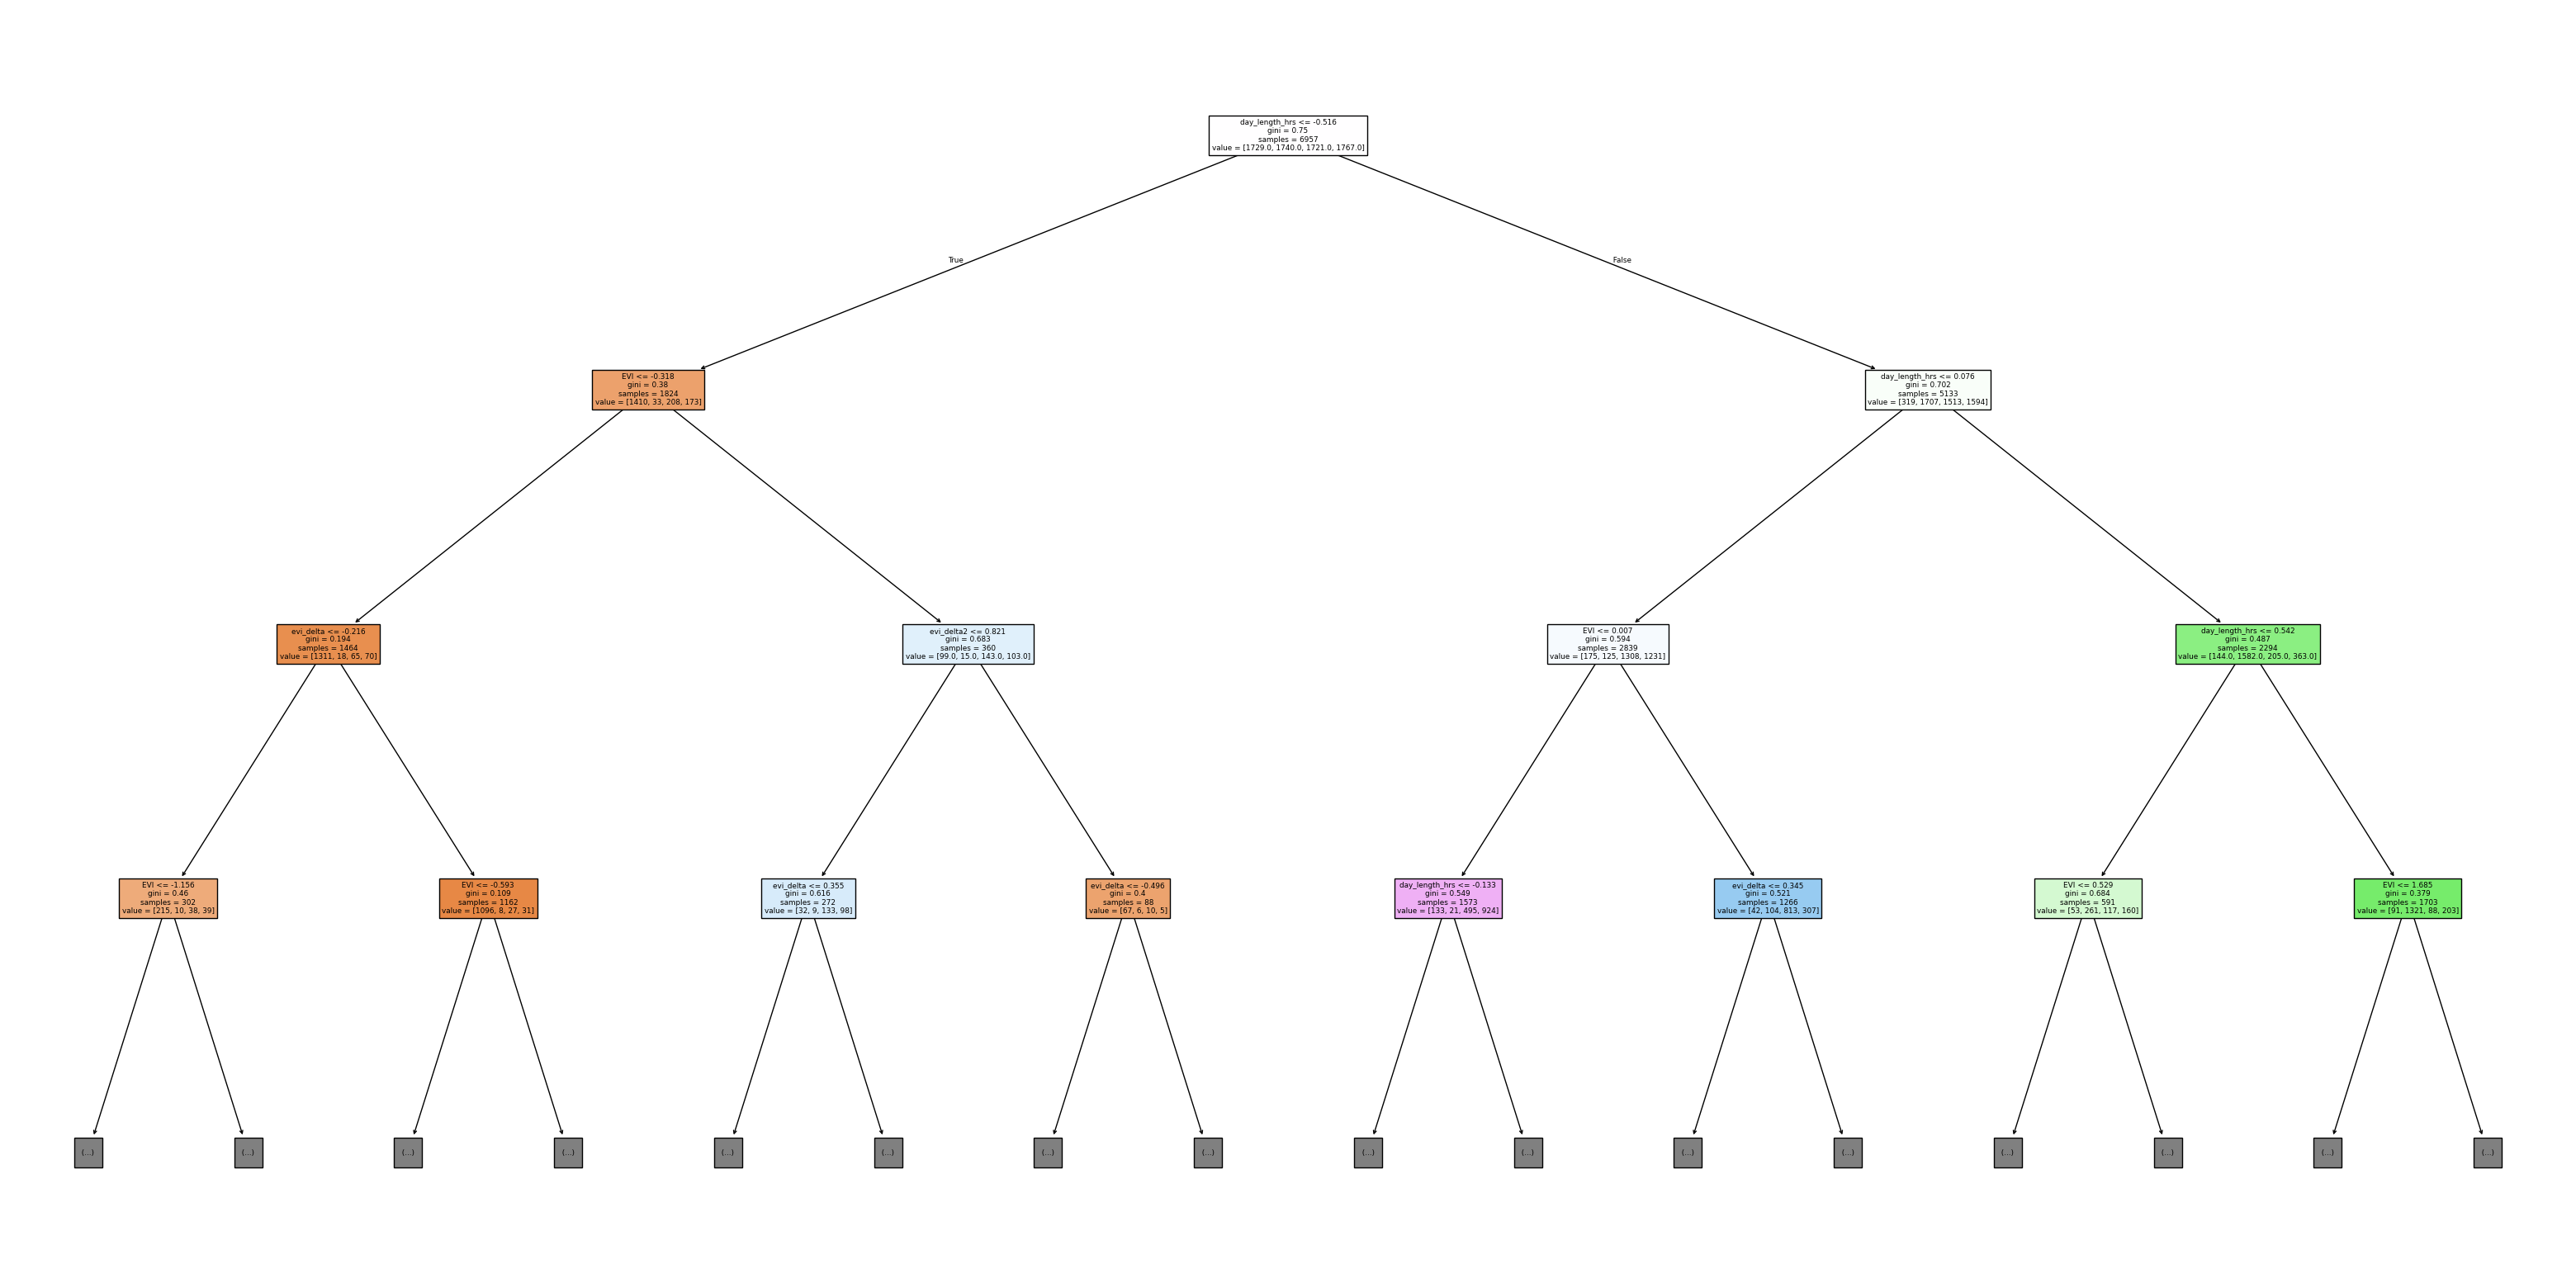

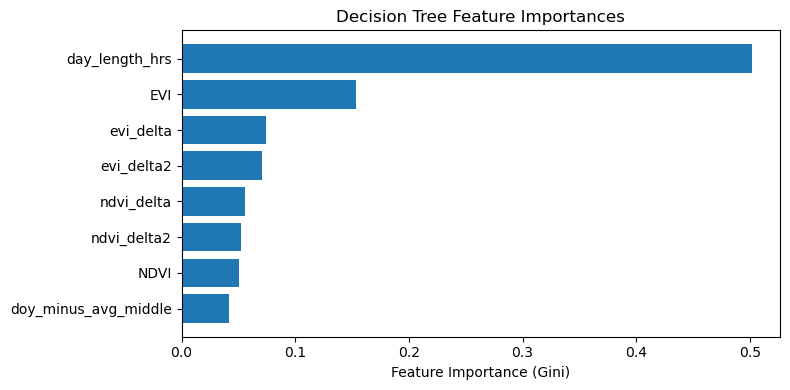


Test Accuracy Score:
0.7416990081931867
              precision    recall  f1-score   support

       after       0.85      0.81      0.83       590
      before       0.80      0.79      0.80       579
       early       0.68      0.68      0.68       598
        late       0.65      0.69      0.67       552

    accuracy                           0.74      2319
   macro avg       0.74      0.74      0.74      2319
weighted avg       0.74      0.74      0.74      2319


Train Accuracy Score:
1.0
              precision    recall  f1-score   support

       after       1.00      1.00      1.00      1729
      before       1.00      1.00      1.00      1740
       early       1.00      1.00      1.00      1721
        late       1.00      1.00      1.00      1767

    accuracy                           1.00      6957
   macro avg       1.00      1.00      1.00      6957
weighted avg       1.00      1.00      1.00      6957



In [8]:
# ----------------------------
# Build decision tree
# ----------------------------
x_train, x_test, y_train, y_test = split_data(feature_df_edited)
mdl = fit_tree(x_train, y_train)

# ----------------------------
# Visualize decision tree
# ----------------------------
# Plot and save tree
fig, ax = plt.subplots(figsize=(40, 20))
tree.plot_tree(mdl, feature_names=list(x_train.columns), filled=True, max_depth=3, ax=ax)
fig.savefig(os.path.join(OUTPUT_DIR, 'decision_tree.png'), dpi=150, bbox_inches='tight')
plt.show()

# Plot feature importances
importances = mdl.feature_importances_
feature_names = list(x_train.columns)
sorted_idx = sorted(range(len(importances)), key=lambda i: importances[i], reverse=True)

fig, ax = plt.subplots(figsize=(8, max(4, len(feature_names) * 0.4)))
ax.barh([feature_names[i] for i in sorted_idx], [importances[i] for i in sorted_idx])
ax.set_xlabel('Feature Importance (Gini)')
ax.set_title('Decision Tree Feature Importances')
ax.invert_yaxis()
plt.tight_layout()
fig.savefig(os.path.join(OUTPUT_DIR, 'feature_importances.png'), dpi=150, bbox_inches='tight')
plt.show()

# ----------------------------
# Test on test data
# ----------------------------
y_pred = mdl.predict(x_test)

# ----------------------------
# Evaluate model
# ----------------------------
print('\nTest Accuracy Score:')
print(accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

#Check for overfitting by comparing accuracy of predicting training data to predicting test data
y_pred_train = mdl.predict(x_train)
print('\nTrain Accuracy Score:')
print(accuracy_score(y_train, y_pred_train))
print(classification_report(y_train, y_pred_train))
#Take-away: without pruning the accuracy on the training data is 1 and the accuracy on the testing data in 0.75 so the model is overfitting
